# Cohort Construction, Figure 1 and Table 1

Defines the study population, produces the cohort flow diagram and the baseline
characteristics table.

This notebook runs **before** the rest of the pipeline: folders 1-3 do not touch
patient data, and folder 4 evaluates the selected features in the cohort defined here.

| step | output |
|---|---|
| exclusion cascade | `outputs/cohort_flow_table.csv` |
| Figure 1 | `outputs/Figure1_cohort_flow.png` / `.pdf` |
| Figure 1 caption | `outputs/Figure1_caption.txt` |
| Table 1 (data) | `outputs/Table1_baseline_characteristics.csv` |
| Table 1 (image) | `outputs/Table1_p*.png`, `outputs/Table1.pdf` |
| Supplement | `outputs/TableS_category_levels_full.csv` |

**Data access.** MIMIC-IV v3.1 is available to credentialed PhysioNet users under a
data use agreement. No patient-level data are stored in this repository. The counts
behind Figure 1 are cached in `outputs/cohort_flow_counts.csv`, which contains
aggregate numbers only, so the figure can be regenerated without database access.
Table 1 requires the extracted feature table and therefore database access.

## §0. Configuration

In [39]:
# =============================================================================
# 0. Configuration
#   The cohort query runs against MIMIC-IV v3.1 on Google BigQuery and requires
#   PhysioNet credentialing. Counts are cached to CSV after the first run so the
#   figure can be regenerated without database access.
# =============================================================================
import os
import numpy as np
import pandas as pd

PROJECT_ID = os.environ.get('BQ_PROJECT', 'yonsei1')   # your own billing project
MIMIC_HOSP = 'physionet-data.mimiciv_3_1_hosp'
MIMIC_ICU  = 'physionet-data.mimiciv_3_1_icu'
MIMIC_DERIVED = 'physionet-data.mimiciv_3_1_derived'

HERE  = os.path.dirname(os.path.abspath('.')) if '__file__' not in dir() else os.getcwd()
OUT   = 'outputs'
os.makedirs(OUT, exist_ok=True)
COUNTS_CSV = os.path.join(OUT, 'cohort_flow_counts.csv')

# Observation window and outcome definition
WINDOW_H      = 24    # hours after ICU admission used for predictors
EARLY_DEATH_H = 48    # deaths within this window are excluded
RASS_ITEMID   = 228096
CAM_ITEMIDS   = {'ms_change':   (228300, 228337, 229326),
                 'inattention': (228301, 228336, 229325),
                 'rass_loc':    (228302, 228334),
                 'disorg':      (228303, 228335, 229324)}

print(f'project      : {PROJECT_ID}')
print(f'window       : first {WINDOW_H} h after ICU admission')
print(f'cache        : {COUNTS_CSV}')

project      : yonsei1
window       : first 24 h after ICU admission
cache        : outputs\cohort_flow_counts.csv


## §1. Cohort definition

In [40]:
# =============================================================================
# 1. Cohort query
#   Mirrors delirium_patients.sql exactly. Kept here so that the flow diagram and
#   the cohort table are generated from a single definition.
#
#   Outcome
#     A CAM-ICU assessment is positive when acute mental status change and
#     inattention are both present and either altered level of consciousness or
#     disorganized thinking is additionally present. The algorithm terminates
#     early when a preceding feature is negative, so features 3 and 4 are not
#     recorded for every assessment; requiring all four would discard most
#     positive assessments. Only features 1 and 2 are required to be documented.
#
#     Delirium is assigned when at least one positive assessment occurs more than
#     WINDOW_H hours after admission at a time point with a concurrent RASS of -3
#     or higher recorded within 60 minutes, which excludes assessments made under
#     deep sedation.
# =============================================================================
COHORT_SQL = f"""
WITH coma_rass AS (
  SELECT DISTINCT ce.stay_id
  FROM `{MIMIC_ICU}.chartevents` ce
  JOIN `{MIMIC_ICU}.icustays` icu USING (stay_id)
  WHERE ce.itemid = {RASS_ITEMID} AND ce.valuenum IS NOT NULL AND ce.valuenum <= -4
    AND ce.charttime BETWEEN icu.intime
                         AND TIMESTAMP_ADD(icu.intime, INTERVAL {WINDOW_H} HOUR)
),
cam_labeled AS (
  SELECT ce.stay_id, ce.charttime, ce.valuenum,
    ce.charttime > TIMESTAMP_ADD(icu.intime, INTERVAL {WINDOW_H} HOUR) AS is_after_window,
    CASE WHEN ce.itemid IN {CAM_ITEMIDS['ms_change']}   THEN 'ms_change'
         WHEN ce.itemid IN {CAM_ITEMIDS['inattention']} THEN 'inattention'
         WHEN ce.itemid IN {CAM_ITEMIDS['rass_loc']}    THEN 'rass_loc'
         WHEN ce.itemid IN {CAM_ITEMIDS['disorg']}      THEN 'disorg' END AS category
  FROM `{MIMIC_ICU}.chartevents` ce
  JOIN `{MIMIC_ICU}.icustays` icu USING (stay_id)
  WHERE ce.itemid IN {tuple(sum(map(list, CAM_ITEMIDS.values()), []))}
    AND ce.charttime >= icu.intime
),
cam_pivoted AS (
  SELECT stay_id, charttime, is_after_window,
    MAX(IF(category = 'ms_change',   valuenum, NULL)) AS ms_change,
    MAX(IF(category = 'inattention', valuenum, NULL)) AS inattention,
    MAX(IF(category = 'rass_loc',    valuenum, NULL)) AS rass_loc,
    MAX(IF(category = 'disorg',      valuenum, NULL)) AS disorg
  FROM cam_labeled
  GROUP BY stay_id, charttime, is_after_window
  HAVING ms_change IS NOT NULL AND inattention IS NOT NULL
),
early_delirium AS (
  SELECT DISTINCT stay_id FROM cam_pivoted
  WHERE NOT is_after_window AND ms_change = 1.0 AND inattention = 1.0
    AND (rass_loc = 1.0 OR disorg = 1.0)
),
base AS (
  -- Age is taken from the MIMIC-IV derived age concept (age at hospital
  -- admission), not from patients.anchor_age, which is the age at the shifted
  -- anchor year. Both give the same result for the >= 18 criterion because the
  -- database contains no minors, but the definition is kept consistent with the
  -- feature extraction step.
  SELECT i.stay_id, i.subject_id, ag.age AS age, adm.deathtime, i.intime,
    ROW_NUMBER() OVER (PARTITION BY i.subject_id ORDER BY i.intime) AS rn,
    TIMESTAMP_DIFF(i.outtime, i.intime, HOUR) AS icu_hours
  FROM `{MIMIC_ICU}.icustays` i
  JOIN `{MIMIC_HOSP}.patients` p    USING (subject_id)
  JOIN `{MIMIC_HOSP}.admissions` adm USING (hadm_id)
  LEFT JOIN `{MIMIC_DERIVED}.age` ag USING (hadm_id)
),
flags AS (
  SELECT b.*,
    b.rn = 1                                    AS f_first_stay,
    b.age >= 18                                 AS f_adult,
    b.icu_hours >= {WINDOW_H}                   AS f_los,
    (b.deathtime IS NULL
     OR TIMESTAMP_DIFF(b.deathtime, b.intime, HOUR) > {EARLY_DEATH_H}) AS f_alive,
    b.stay_id NOT IN (SELECT stay_id FROM coma_rass)       AS f_no_coma,
    b.stay_id NOT IN (SELECT stay_id FROM early_delirium)  AS f_no_early
  FROM base b
)
SELECT
  COUNT(*)                                                          AS n0_all_icu_stays,
  COUNTIF(f_first_stay)                                             AS n1_first_stay,
  COUNTIF(f_first_stay AND f_adult)                                 AS n2_adult,
  COUNTIF(f_first_stay AND f_adult AND f_los)                       AS n3_los,
  COUNTIF(f_first_stay AND f_adult AND f_los AND f_alive)           AS n4_alive,
  COUNTIF(f_first_stay AND f_adult AND f_los AND f_alive
          AND f_no_coma)                                            AS n5_no_coma,
  COUNTIF(f_first_stay AND f_adult AND f_los AND f_alive
          AND f_no_coma AND f_no_early)                             AS n6_final
FROM flags
"""
print(f'query length: {len(COHORT_SQL):,} characters')

query length: 3,717 characters


## §2. Exclusion cascade

In [41]:
# =============================================================================
# 2. Run the query (or reuse the cached counts)
# =============================================================================
if os.path.exists(COUNTS_CSV):
    counts = pd.read_csv(COUNTS_CSV).iloc[0]
    print(f'[cache] {COUNTS_CSV}')
else:
    from google.cloud import bigquery
    client = bigquery.Client(project=PROJECT_ID)
    counts = client.query(COHORT_SQL).to_dataframe().iloc[0]
    counts.to_frame().T.to_csv(COUNTS_CSV, index=False)
    print(f'[query] saved to {COUNTS_CSV}')

STEPS = [
    ('n0_all_icu_stays', 'ICU stays in MIMIC-IV v3.1',            None),
    ('n1_first_stay',    'First ICU stay per patient',            'Repeat ICU stays'),
    ('n2_adult',         'Age >= 18 years',                       'Age < 18 years'),
    ('n3_los',           f'ICU stay >= {WINDOW_H} h',             f'ICU stay < {WINDOW_H} h'),
    ('n4_alive',         f'Survived > {EARLY_DEATH_H} h',         f'Died within {EARLY_DEATH_H} h'),
    ('n5_no_coma',       f'No coma in first {WINDOW_H} h',        f'RASS <= -4 within {WINDOW_H} h'),
    ('n6_final',         'Analysis cohort',                       f'CAM-ICU positive within {WINDOW_H} h'),
]

flow = []
prev = None
for key, keep, drop in STEPS:
    n = int(counts[key])
    flow.append({'step': key, 'kept_label': keep, 'excluded_label': drop,
                 'n_remaining': n,
                 'n_excluded': (prev - n) if prev is not None else np.nan})
    prev = n
flow = pd.DataFrame(flow)
flow.to_csv(os.path.join(OUT, 'cohort_flow_table.csv'), index=False, encoding='utf-8-sig')
display(flow)

N_FINAL = int(counts['n6_final'])
print(f'\nanalysis cohort: {N_FINAL:,} ICU stays')

[cache] outputs\cohort_flow_counts.csv


,step,kept_label,excluded_label,n_remaining,n_excluded
0,n0_all_icu_stays,ICU stays in MIMIC-IV v3.1,NaN,94458,NaN
1,n1_first_stay,First ICU stay per patient,Repeat ICU stays,65366,29092.0
2,n2_adult,Age >= 18 years,Age < 18 years,65366,0.0
3,n3_los,ICU stay >= 24 h,ICU stay < 24 h,52447,12919.0
4,n4_alive,Survived > 48 h,Died within 48 h,51397,1050.0
5,n5_no_coma,No coma in first 24 h,RASS <= -4 within 24 h,37590,13807.0
6,n6_final,Analysis cohort,CAM-ICU positive within 24 h,32574,5016.0



analysis cohort: 32,574 ICU stays


## §3. Figure 1

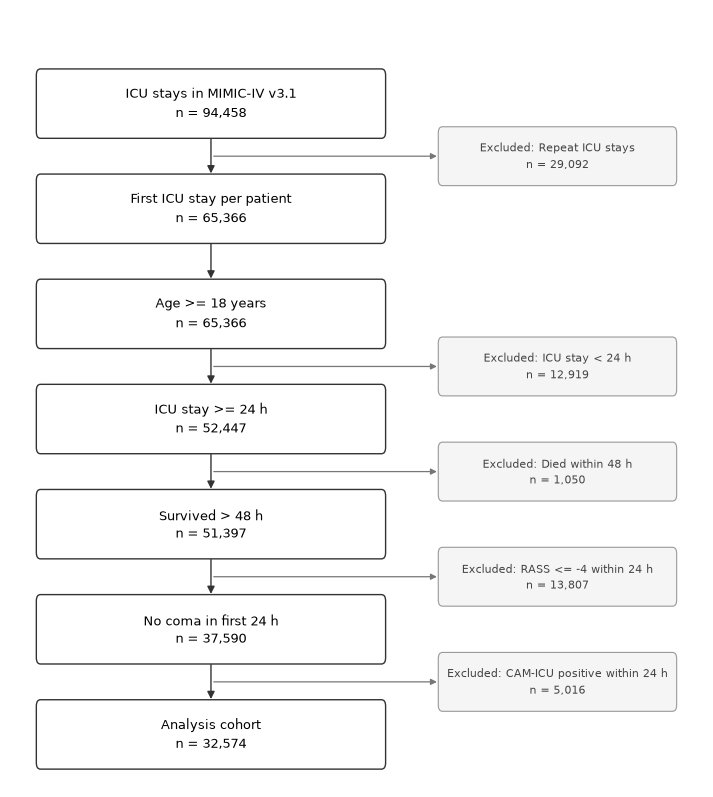

saved: outputs/Figure1_cohort_flow.png / .pdf


In [42]:
# =============================================================================
# 3. Figure 1 - cohort flow diagram
# =============================================================================
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

matplotlib.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 9,
                            'axes.unicode_minus': False})

rows   = flow.to_dict('records')
n_rows = len(rows)
fig, ax = plt.subplots(figsize=(7.2, 1.15 * n_rows))
ax.set_xlim(0, 10); ax.set_ylim(0, n_rows + 0.4); ax.axis('off')

BOX_X, BOX_W, BOX_H = 0.4, 5.0, 0.62
EXC_X, EXC_W        = 6.2, 3.4

for i, r in enumerate(rows):
    y = n_rows - i - 0.5
    ax.add_patch(FancyBboxPatch((BOX_X, y - BOX_H / 2), BOX_W, BOX_H,
                                boxstyle='round,pad=0.02,rounding_size=0.06',
                                linewidth=1.0, edgecolor='#333333', facecolor='white'))
    ax.text(BOX_X + BOX_W / 2, y, f"{r['kept_label']}\nn = {r['n_remaining']:,}",
            ha='center', va='center', linespacing=1.5)

    if i < n_rows - 1:
        nxt = rows[i + 1]
        ax.add_patch(FancyArrowPatch((BOX_X + BOX_W / 2, y - BOX_H / 2),
                                     (BOX_X + BOX_W / 2, y - 1 + BOX_H / 2),
                                     arrowstyle='-|>', mutation_scale=11,
                                     linewidth=1.0, color='#333333'))
        if pd.notna(nxt['n_excluded']) and nxt['n_excluded'] > 0:
            ye = y - 0.5
            ax.add_patch(FancyArrowPatch((BOX_X + BOX_W / 2, ye), (EXC_X, ye),
                                         arrowstyle='-|>', mutation_scale=9,
                                         linewidth=0.9, color='#777777'))
            ax.add_patch(FancyBboxPatch((EXC_X, ye - 0.26), EXC_W, 0.52,
                                        boxstyle='round,pad=0.02,rounding_size=0.06',
                                        linewidth=0.8, edgecolor='#999999',
                                        facecolor='#f5f5f5'))
            ax.text(EXC_X + EXC_W / 2, ye,
                    f"Excluded: {nxt['excluded_label']}\nn = {int(nxt['n_excluded']):,}",
                    ha='center', va='center', fontsize=8, color='#444444', linespacing=1.5)

fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(os.path.join(OUT, f'Figure1_cohort_flow.{ext}'), dpi=300,
                bbox_inches='tight')
plt.show()
print('saved: outputs/Figure1_cohort_flow.png / .pdf')

## §4. Figure 1 caption

In [43]:
# =============================================================================
# 4. Caption text for the manuscript
# =============================================================================
r = {row['step']: row for row in flow.to_dict('records')}
caption = (
    f"Figure 1. Cohort selection. Of {r['n0_all_icu_stays']['n_remaining']:,} ICU stays "
    f"recorded in MIMIC-IV v{'3.1'}, only the first stay of each patient was retained "
    f"({r['n1_first_stay']['n_remaining']:,}). Stays shorter than {WINDOW_H} hours "
    f"(n = {int(r['n3_los']['n_excluded']):,}) and patients who died within "
    f"{EARLY_DEATH_H} hours of admission (n = {int(r['n4_alive']['n_excluded']):,}) "
    f"were excluded, as delirium could not be observed beyond the prediction window. "
    f"Patients with a RASS score of -4 or lower during the first {WINDOW_H} hours "
    f"(n = {int(r['n5_no_coma']['n_excluded']):,}) were excluded because delirium "
    f"cannot be assessed under coma, and patients already CAM-ICU positive within "
    f"the first {WINDOW_H} hours (n = {int(r['n6_final']['n_excluded']):,}) were "
    f"excluded so that only incident delirium was modelled. "
    f"The analysis cohort comprised {r['n6_final']['n_remaining']:,} ICU stays."
)
with open(os.path.join(OUT, 'Figure1_caption.txt'), 'w', encoding='utf-8') as f:
    f.write(caption + '\n')
print(caption)

Figure 1. Cohort selection. Of 94,458 ICU stays recorded in MIMIC-IV v3.1, only the first stay of each patient was retained (65,366). Stays shorter than 24 hours (n = 12,919) and patients who died within 48 hours of admission (n = 1,050) were excluded, as delirium could not be observed beyond the prediction window. Patients with a RASS score of -4 or lower during the first 24 hours (n = 13,807) were excluded because delirium cannot be assessed under coma, and patients already CAM-ICU positive within the first 24 hours (n = 5,016) were excluded so that only incident delirium was modelled. The analysis cohort comprised 32,574 ICU stays.


## §5. Table 1 — baseline characteristics

**Depends on** `4. evaluation with MIMIC-IV/mimic_iv_dataset_107`. Export that table after
running `mimic_iv_107.sql`, then run this section.

Continuous variables are reported as median (Q1, Q3) and compared with the Mann-Whitney U
test; categorical variables as n (%) with the chi-squared test, or Fisher's exact test when
an expected cell count falls below 5.

The standardised mean difference is reported alongside the p value. With n = 32,574 a
difference of no clinical consequence still reaches p < 0.001, so |SMD| > 0.1 is used to
flag meaningful imbalance.

Variable type is decided by whether the column can be coerced to a number, not by its
pandas dtype: BigQuery `NUMERIC` columns arrive as `decimal.Decimal` in `object` dtype and
would otherwise be mistaken for text.

In [44]:
# =============================================================================
# 5. Table 1 - baseline characteristics
#   Requires the extracted feature table produced by
#   `4. evaluation with MIMIC-IV/mimic_iv_107.sql`. Run that step first.
#
#   Continuous variables : median (IQR), Mann-Whitney U test
#   Categorical variables: n (%), chi-squared test, or Fisher's exact test when
#                          any expected cell count is below 5
#   Standardised mean difference is reported alongside the p value because with
#   n = 32,574 trivial differences reach significance; |SMD| > 0.1 is the
#   conventional threshold for a meaningful imbalance.
# =============================================================================
from scipy import stats

DATA_CANDIDATES = [
    os.path.join('..', '4. evaluation with MIMIC-IV', 'mimic_iv_dataset_107'),
    os.path.join('..', '4. evaluation with MIMIC-IV', 'mimic_iv_dataset_107.csv'),
]
DATA_FILE = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if DATA_FILE is None:
    raise FileNotFoundError('Run mimic_iv_107.sql first, then export the table to '
                            '4. evaluation with MIMIC-IV/mimic_iv_dataset_107')

df = pd.read_csv(DATA_FILE, low_memory=False)

# BigQuery NUMERIC columns arrive as decimal.Decimal and land in object dtype,
# which breaks scipy's numeric routines. Coerce any object column that is in fact
# numeric to float, leaving genuine text columns untouched.
TEXT_COLS = {'delirium_charttime', 'deathtime', 'intime', 'outtime', 'sex',
             'ethnicity', 'insurance', 'marital_status', 'micro_category',
             'cardiac_surgery_type', 'type_of_initial_icu_admission'}
_coerced = []
for c in df.columns:
    if c in TEXT_COLS or df[c].dtype != object:
        continue
    conv = pd.to_numeric(df[c], errors='coerce')
    if conv.notna().sum() >= df[c].notna().sum() * 0.99:   # essentially all numeric
        df[c] = conv.astype(float)
        _coerced.append(c)
if _coerced:
    print(f'coerced to float: {len(_coerced)} columns -> {_coerced[:6]}'
          f'{" ..." if len(_coerced) > 6 else ""}')

GROUP = 'delirium'
g1 = df[df[GROUP].astype(bool)]      # delirium
g0 = df[~df[GROUP].astype(bool)]     # no delirium
print(f'{DATA_FILE}  ->  {len(df):,} stays')
print(f'  delirium    : {len(g1):,} ({100*len(g1)/len(df):.2f}%)')
print(f'  no delirium : {len(g0):,}')

..\4. evaluation with MIMIC-IV\mimic_iv_dataset_107  ->  32,574 stays
  delirium    : 2,728 (8.37%)
  no delirium : 29,846


In [45]:
# =============================================================================
# 5-2. Variable list for Table 1
#   Edit here to change what appears in the table. `None` as the label falls back
#   to the column name. Continuous and binary variables are detected automatically.
# =============================================================================
TABLE1_SPEC = [
    ('Demographics', [
        ('anchor_age',                    'Age, years'),
        ('sex',                           'Male sex'),
        ('height',                        'Height, cm'),
        ('weight',                        'Weight, kg'),
        ('body_mass_index',               'Body mass index, kg/m2'),
        ('ethnicity',                     'Race or ethnicity'),
        ('insurance',                     'Insurance'),
        ('type_of_initial_icu_admission', 'First ICU care unit'),
    ]),
    ('Severity on admission', [
        ('sofa_score',                             'SOFA'),
        ('apache_score',                           'APS III'),
        ('simplified_acute_physiology_score_ii',   'SAPS II'),
        ('oxford_acute_severity_of_illness_score', 'OASIS'),
        ('logistic_organ_dysfunction_score',       'LODS'),
        ('gcs_min',                                'GCS, minimum'),
        ('charlson_comorbidity_index',             'Charlson Comorbidity Index'),
    ]),
    ('Vital signs, first 24 h', [
        ('heart_rate_max',              'Heart rate, maximum, bpm'),
        ('systolic_blood_pressure_min', 'Systolic BP, minimum, mmHg'),
        ('mean_blood_pressure_min',     'Mean BP, minimum, mmHg'),
        ('respiratory_rate_max',        'Respiratory rate, maximum, /min'),
        ('temperature_max',             'Temperature, maximum, C'),
        ('oxygen_saturation_min',       'SpO2, minimum, %'),
    ]),
    ('Laboratory tests, first 24 h', [
        ('white_blood_cell_count_max', 'White blood cells, maximum, K/uL'),
        ('hemoglobin_min',             'Haemoglobin, minimum, g/dL'),
        ('platelet_count_min',         'Platelets, minimum, K/uL'),
        ('creatinine_max',             'Creatinine, maximum, mg/dL'),
        ('blood_urea_nitrogen_max',    'Blood urea nitrogen, maximum, mg/dL'),
        ('blood_sodium_min',           'Sodium, minimum, mEq/L'),
        ('glucose_max',                'Glucose, maximum, mg/dL'),
        ('albumin_min',                'Albumin, minimum, g/dL'),
        ('lactate_max',                'Lactate, maximum, mmol/L'),
        ('anion_gap_max',              'Anion gap, maximum, mEq/L'),
        ('blood_ph_min',               'pH, minimum'),
        ('egfr',                       'eGFR, mL/min/1.73m2'),
    ]),
    ('Comorbidities', [
        ('hypertension',                'Hypertension'),
        ('diabetes',                    'Diabetes'),
        ('heart_failure',               'Heart failure'),
        ('cardiovascular_disease',      'Cardiovascular disease'),
        ('copd',                        'COPD'),
        ('renal_disease',               'Renal disease'),
        ('liver_disease',               'Liver disease'),
        ('cancer',                      'Cancer'),
        ('cerebrovascular_disease',     'Cerebrovascular disease'),
        ('dementia',                    'Dementia'),
        ('depression',                  'Depression'),
        ('alcohol_abuse',               'Alcohol abuse'),
        ('has_anemia',                  'Anaemia'),
        ('nicotine_dependence',         'Nicotine dependence'),
    ]),
    ('Acute conditions and treatments, first 24 h', [
        ('sepsis',                    'Sepsis'),
        ('infection',                 'Infection'),
        ('acute_kidney_injury',       'Acute kidney injury, KDIGO stage'),
        ('mechanical_ventilation',    'Mechanical ventilation'),
        ('vasopressor_use',           'Vasopressor use'),
        ('renal_replacement_therapy', 'Renal replacement therapy'),
        ('sedation_use',              'Sedation'),
        ('use_of_midazolam',          'Midazolam'),
        ('antibiotic_drug_use',       'Antibiotics'),
        ('urine_output',              'Urine output, mL'),
    ]),
]
n_spec = sum(len(v) for _, v in TABLE1_SPEC)
missing_cols = [c for _, items in TABLE1_SPEC for c, _ in items if c not in df.columns]
assert not missing_cols, f'not in dataset: {missing_cols}'
print(f'{n_spec} variables in {len(TABLE1_SPEC)} sections')

# =============================================================================
# 5-2b. Collapsing high-cardinality categories
#   MIMIC-IV records 33 race/ethnicity levels and 14 first care units. Listing all
#   of them makes Table 1 unreadable and most cells hold fewer than 1% of the
#   cohort. Levels are collapsed to the groups conventionally reported in the
#   MIMIC literature; the full uncollapsed breakdown is written to the
#   Supplementary file below.
# =============================================================================
def _collapse_ethnicity(v):
    if pd.isna(v):
        return 'Unknown'
    u = str(v).upper()
    if u.startswith('WHITE'):                       return 'White'
    if u.startswith('BLACK'):                       return 'Black'
    if u.startswith('HISPANIC'):                    return 'Hispanic'
    if u.startswith('ASIAN'):                       return 'Asian'
    if u.startswith(('AMERICAN INDIAN', 'NATIVE')): return 'Other'
    if u in ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER'):
        return 'Unknown'
    return 'Other'


def _collapse_icu(v):
    if pd.isna(v):
        return 'Other'
    s = str(v)
    for key, short in [('MICU/SICU', 'MICU/SICU'), ('Neuro Surgical', 'Neuro SICU'),
                       ('Medical Intensive', 'MICU'), ('Surgical Intensive', 'SICU'),
                       ('Coronary', 'CCU'), ('Trauma SICU', 'TSICU'),
                       ('Cardiac Vascular', 'CVICU'), ('Neuro Intermediate', 'Neuro intermediate'),
                       ('Neuro Stepdown', 'Neuro stepdown')]:
        if key in s:
            return short
    return 'Other'


# Full uncollapsed breakdown for the supplement, written before collapsing
_full = []
for c in ['ethnicity', 'type_of_initial_icu_admission']:
    vc = df[c].fillna('Unknown').value_counts()
    for level, n in vc.items():
        m = df[c].fillna('Unknown') == level
        _full.append({'variable': c, 'level': level, 'n': int(n),
                      'pct': round(100 * n / len(df), 2),
                      'n_delirium': int((m & df[GROUP].astype(bool)).sum())})
pd.DataFrame(_full).to_csv(
    os.path.join(OUT, 'TableS_category_levels_full.csv'), index=False, encoding='utf-8-sig')

df['ethnicity'] = df['ethnicity'].map(_collapse_ethnicity)
df['type_of_initial_icu_admission'] = df['type_of_initial_icu_admission'].map(_collapse_icu)
g1 = df[df[GROUP].astype(bool)]
g0 = df[~df[GROUP].astype(bool)]

print('collapsed  ethnicity :', df.ethnicity.nunique(), 'levels ->',
      sorted(df.ethnicity.unique()))
print('collapsed  ICU unit  :', df.type_of_initial_icu_admission.nunique(), 'levels')
print('full breakdown saved : outputs/TableS_category_levels_full.csv')

57 variables in 6 sections
collapsed  ethnicity : 6 levels -> ['Asian', 'Black', 'Hispanic', 'Other', 'Unknown', 'White']
collapsed  ICU unit  : 10 levels
full breakdown saved : outputs/TableS_category_levels_full.csv


In [46]:
# =============================================================================
# 5-3. Summary and test functions
# =============================================================================
BINARY_AS_PERCENT = True     # 0/1 columns are reported as n (%) of the "1" level

def _num(s):
    """Coerce to float. BigQuery NUMERIC arrives as decimal.Decimal in object dtype."""
    return pd.to_numeric(s, errors='coerce')


def _kind(s):
    """'binary' | 'continuous' | 'categorical' - decided by coercibility, not dtype."""
    obs = s.dropna()
    if len(obs) == 0:
        return 'continuous'
    conv = _num(obs)
    if conv.notna().sum() < len(obs) * 0.99:      # genuine text
        return 'categorical'
    v = set(conv.dropna().unique())
    return 'binary' if v <= {0, 1, 0.0, 1.0} else 'continuous'


def _smd_cont(a, b):
    a, b = a.dropna(), b.dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return np.nan if sp == 0 else (a.mean() - b.mean()) / sp


def _smd_prop(p1, p0):
    pb = (p1 + p0) / 2
    d = np.sqrt(pb * (1 - pb))
    return np.nan if d == 0 else (p1 - p0) / d


def _fmt_med(s):
    s = pd.to_numeric(s, errors='coerce').dropna()
    if len(s) == 0:
        return '-'
    q1, q2, q3 = s.quantile([.25, .5, .75])
    return f'{q2:.1f} ({q1:.1f}, {q3:.1f})'


def summarise(col, label):
    """-> list of row dicts (one row for binary/continuous, several for multi-level)"""
    s_all, s1, s0 = df[col], g1[col], g0[col]
    miss = 100 * s_all.isna().mean()
    kind = _kind(s_all)

    # multi-level categorical -> one row per level
    if kind == 'categorical':
        lv = s_all.fillna('Unknown')
        l1, l0 = g1[col].fillna('Unknown'), g0[col].fillna('Unknown')
        ct = pd.crosstab(lv, df[GROUP].astype(bool))
        try:
            chi2, p, dof, exp = stats.chi2_contingency(ct)
            test = 'chi2' if (exp >= 5).all() else 'chi2 (expected < 5)'
        except ValueError:
            p, test = np.nan, 'n/a'
        rows = [{'Variable': label, 'Overall': '', 'No delirium': '', 'Delirium': '',
                 'p': f'{p:.3f}' if p >= .001 else '<0.001', 'SMD': '',
                 'Missing %': f'{miss:.1f}', 'Test': test}]
        for level in sorted(lv.unique(), key=str):
            n_all, n1, n0 = (lv == level).sum(), (l1 == level).sum(), (l0 == level).sum()
            rows.append({'Variable': f'    {level}',
                         'Overall':     f'{n_all:,} ({100*n_all/len(lv):.1f})',
                         'No delirium': f'{n0:,} ({100*n0/len(l0):.1f})',
                         'Delirium':    f'{n1:,} ({100*n1/len(l1):.1f})',
                         'p': '', 'SMD': f'{_smd_prop(n1/len(l1), n0/len(l0)):+.3f}',
                         'Missing %': '', 'Test': ''})
        return rows

    # binary
    if kind == 'binary':
        b_all = _num(s_all).fillna(0).astype(int)
        b1    = _num(s1).fillna(0).astype(int)
        b0    = _num(s0).fillna(0).astype(int)
        ct = np.array([[b1.sum(), len(b1) - b1.sum()], [b0.sum(), len(b0) - b0.sum()]])
        try:
            chi2, p, dof, exp = stats.chi2_contingency(ct)
            if (exp < 5).any():
                _, p = stats.fisher_exact(ct); test = 'Fisher'
            else:
                test = 'chi2'
        except ValueError:
            p, test = np.nan, 'n/a'
        return [{'Variable': label,
                 'Overall':     f'{b_all.sum():,} ({100*b_all.mean():.1f})',
                 'No delirium': f'{b0.sum():,} ({100*b0.mean():.1f})',
                 'Delirium':    f'{b1.sum():,} ({100*b1.mean():.1f})',
                 'p': f'{p:.3f}' if p >= .001 else '<0.001',
                 'SMD': f'{_smd_prop(b1.mean(), b0.mean()):+.3f}',
                 'Missing %': f'{miss:.1f}', 'Test': test}]

    # continuous - coerce defensively; a NUMERIC column read straight from
    # BigQuery arrives as decimal.Decimal and would otherwise reach scipy as object
    s_all, s1_n, s0_n = _num(s_all), _num(s1), _num(s0)
    a, b = s1_n.dropna(), s0_n.dropna()
    if len(a) > 1 and len(b) > 1:
        _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    else:
        p = np.nan
    return [{'Variable': label, 'Overall': _fmt_med(s_all),
             'No delirium': _fmt_med(s0_n), 'Delirium': _fmt_med(s1_n),
             'p': f'{p:.3f}' if p >= .001 else '<0.001',
             'SMD': f'{_smd_cont(s1_n, s0_n):+.3f}',
             'Missing %': f'{miss:.1f}', 'Test': 'Mann-Whitney U'}]

In [47]:
# =============================================================================
# 5-4. Build and export Table 1
# =============================================================================
rows = []
for section, items in TABLE1_SPEC:
    rows.append({'Variable': section, 'Overall': '', 'No delirium': '', 'Delirium': '',
                 'p': '', 'SMD': '', 'Missing %': '', 'Test': ''})
    for col, label in items:
        rows.extend(summarise(col, label))

table1 = pd.DataFrame(rows)
table1.to_csv(os.path.join(OUT, 'Table1_baseline_characteristics.csv'),
              index=False, encoding='utf-8-sig')

header = (f'Table 1. Baseline characteristics of the study cohort '
          f'(n = {len(df):,} ICU stays), stratified by incident delirium. '
          f'Continuous variables are median (Q1, Q3) and compared with the '
          f'Mann-Whitney U test; categorical variables are n (%) and compared '
          f'with the chi-squared test, or Fisher exact test when an expected '
          f'count was below 5. SMD, standardised mean difference. Because the '
          f'sample is large, |SMD| > 0.1 is used to flag a meaningful difference '
          f'rather than the p value alone.')
with open(os.path.join(OUT, 'Table1_caption.txt'), 'w', encoding='utf-8') as f:
    f.write(header + '\n')

display(table1)
print('\nsaved: outputs/Table1_baseline_characteristics.csv')

smd = pd.to_numeric(table1['SMD'], errors='coerce').abs()
big = table1.loc[smd > 0.1, ['Variable', 'No delirium', 'Delirium', 'SMD']]
print(f'\n|SMD| > 0.1 : {len(big)} variables')
display(big.reset_index(drop=True))

,Variable,Overall,No delirium,Delirium,p,SMD,Missing %,Test
0,Demographics,,,,,,,
1,"Age, years","66.0 (54.0, 78.0)","66.0 (54.0, 77.0)","71.0 (60.0, 81.0)",<0.001,+0.285,0.0,Mann-Whitney U
2,Male sex,,,,0.897,,0.0,chi2
3,F,"14,965 (45.9)","13,708 (45.9)","1,257 (46.1)",,+0.003,,
4,M,"17,609 (54.1)","16,138 (54.1)","1,471 (53.9)",,-0.003,,
...,...,...,...,...,...,...,...,...
82,Renal replacement therapy,913 (2.8),783 (2.6),130 (4.8),<0.001,+0.114,0.0,chi2
83,Sedation,"7,553 (23.2)","6,718 (22.5)",835 (30.6),<0.001,+0.183,0.0,chi2
84,Midazolam,"2,414 (7.4)","2,154 (7.2)",260 (9.5),<0.001,+0.084,0.0,chi2
85,Antibiotics,"16,213 (49.8)","14,672 (49.2)","1,541 (56.5)",<0.001,+0.147,0.0,chi2



saved: outputs/Table1_baseline_characteristics.csv

|SMD| > 0.1 : 48 variables


,Variable,No delirium,Delirium,SMD
0,"Age, years","66.0 (54.0, 77.0)","71.0 (60.0, 81.0)",+0.285
1,Unknown,"3,128 (10.5)",497 (18.2),+0.221
2,White,"20,551 (68.9)","1,695 (62.1)",-0.141
3,Medicare,"15,480 (51.9)","1,728 (63.3)",+0.232
4,Private,"9,035 (30.3)",536 (19.6),-0.245
5,CCU,"4,244 (14.2)",254 (9.3),-0.152
6,CVICU,"3,585 (12.0)",189 (6.9),-0.174
7,Neuro SICU,357 (1.2),110 (4.0),+0.178
8,SOFA,"3.0 (1.0, 5.0)","4.0 (2.0, 7.0)",+0.493
9,APS III,"36.0 (27.0, 47.0)","46.0 (35.0, 59.0)",+0.528


### §5-5. Rendering Table 1 as a figure

Some journals require tables as images. The layout follows the usual convention of
horizontal rules only, with section headings in bold and category levels indented.
Long tables are split across pages; adjust `ROWS_PER_PAGE` to change the break points.

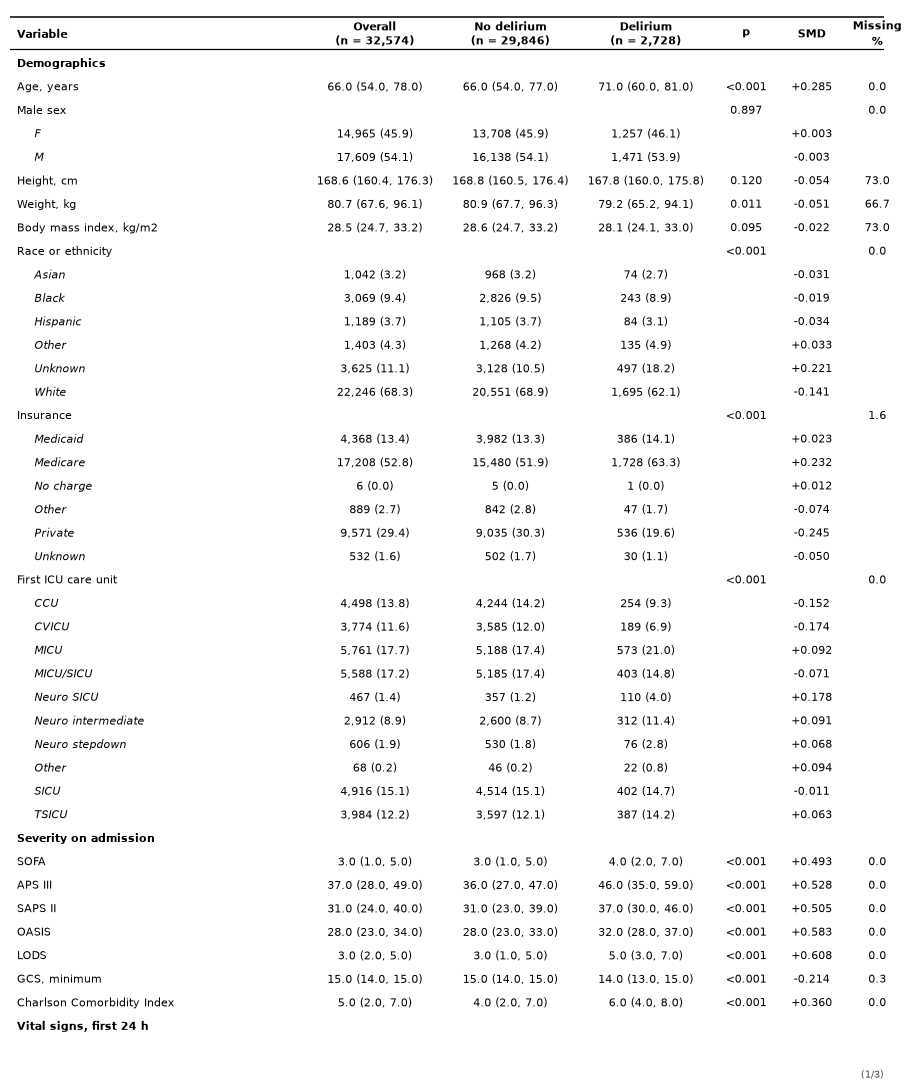

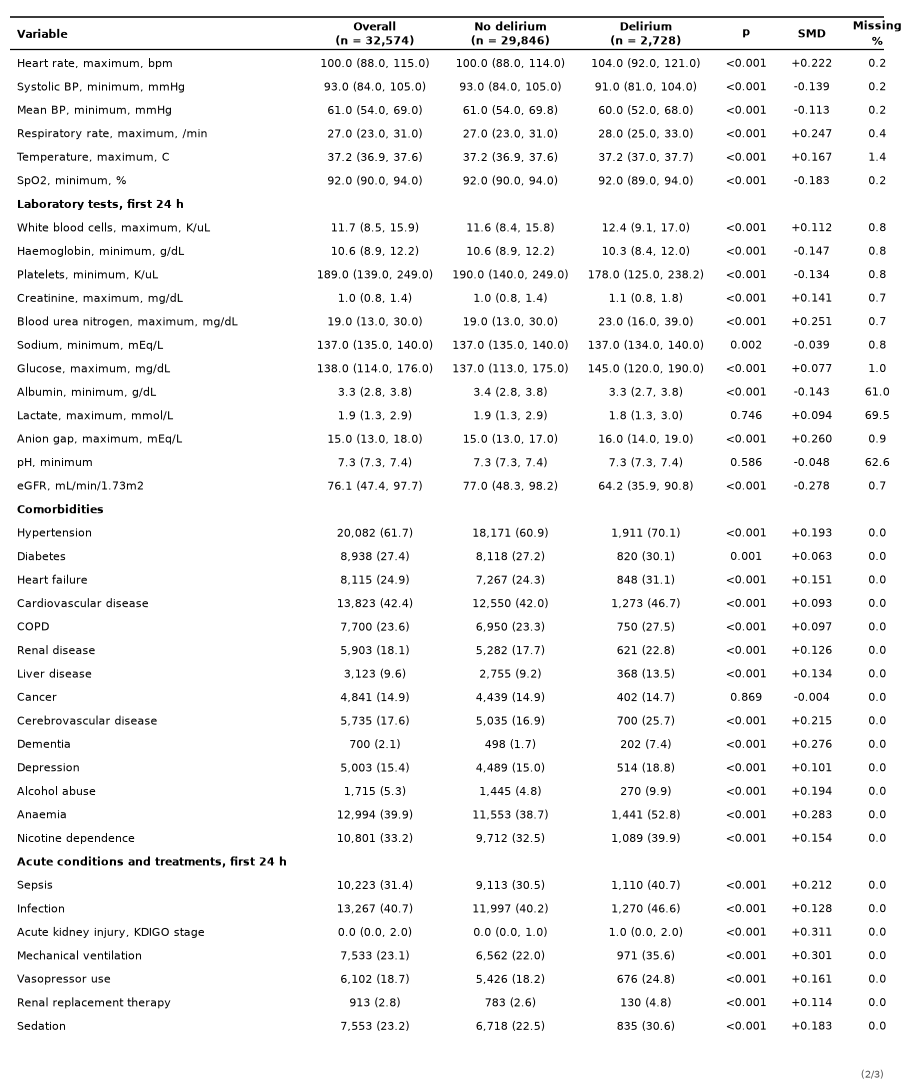

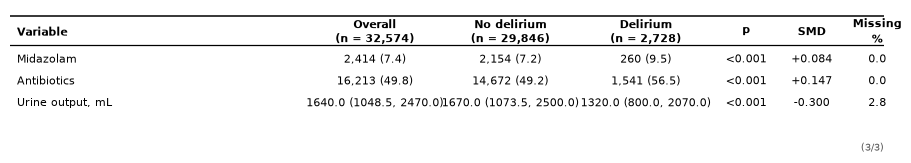

saved: outputs/Table1*.png (3 page(s)) and outputs/Table1.pdf


In [48]:
# =============================================================================
# 5-5. Render Table 1 as an image
#   Journal-style layout: horizontal rules only, section headers in bold,
#   category levels indented. Long tables are split across pages.
# =============================================================================
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.family': 'DejaVu Sans', 'axes.unicode_minus': False})

T1_COLS = ['Variable', 'Overall', 'No delirium', 'Delirium', 'p', 'SMD', 'Missing %']
T1_HEAD = {'Overall':     f'Overall\n(n = {len(df):,})',
           'No delirium': f'No delirium\n(n = {len(g0):,})',
           'Delirium':    f'Delirium\n(n = {len(g1):,})',
           'Missing %':   'Missing\n%'}
T1_W     = [0.34, 0.155, 0.155, 0.155, 0.075, 0.075, 0.075]   # sums to ~1
ROWS_PER_PAGE = 42
ROW_H, FS = 0.235, 8.0

_section_names = {s for s, _ in TABLE1_SPEC}

def _draw_page(sub, page, n_pages):
    n = len(sub)
    fig_h = 1.05 + ROW_H * n
    fig, ax = plt.subplots(figsize=(9.2, fig_h))
    ax.set_xlim(0, 1); ax.set_ylim(0, n + 2.2); ax.axis('off')

    x, xs = 0.0, []
    for w in T1_W:
        xs.append(x); x += w

    y_head = n + 1.2
    ax.plot([0, 1], [n + 1.9, n + 1.9], color='black', lw=1.1)       # top rule
    for i, c in enumerate(T1_COLS):
        label = T1_HEAD.get(c, c)
        ha = 'left' if i == 0 else 'center'
        xp = xs[i] + (0.008 if i == 0 else T1_W[i] / 2)
        ax.text(xp, y_head, label, ha=ha, va='center', fontsize=FS,
                fontweight='bold', linespacing=1.35)
    ax.plot([0, 1], [n + 0.55, n + 0.55], color='black', lw=0.9)     # header rule

    for r, (_, row) in enumerate(sub.iterrows()):
        y = n - r - 0.1
        var = str(row['Variable'])
        is_section = var in _section_names
        is_level   = var.startswith('    ')
        if is_section:
            ax.text(xs[0] + 0.008, y, var, ha='left', va='center',
                    fontsize=FS, fontweight='bold')
            continue
        ax.text(xs[0] + (0.028 if is_level else 0.008), y, var.strip(),
                ha='left', va='center', fontsize=FS,
                style='italic' if is_level else 'normal')
        for i in range(1, len(T1_COLS)):
            val = str(row[T1_COLS[i]])
            if val and val != 'nan':
                ax.text(xs[i] + T1_W[i] / 2, y, val, ha='center', va='center',
                        fontsize=FS)
    ax.plot([0, 1], [-0.55, -0.55], color='black', lw=1.1)           # bottom rule
    if n_pages > 1:
        ax.text(1.0, -1.15, f'({page}/{n_pages})', ha='right', va='center',
                fontsize=FS - 1, color='#555555')
    fig.tight_layout()
    return fig

pages = [table1.iloc[i:i + ROWS_PER_PAGE] for i in range(0, len(table1), ROWS_PER_PAGE)]
figs  = [_draw_page(p, i + 1, len(pages)) for i, p in enumerate(pages)]

for i, f in enumerate(figs, 1):
    suffix = '' if len(figs) == 1 else f'_p{i}'
    f.savefig(os.path.join(OUT, f'Table1{suffix}.png'), dpi=300, bbox_inches='tight')

from matplotlib.backends.backend_pdf import PdfPages
with PdfPages(os.path.join(OUT, 'Table1.pdf')) as pdf:
    for f in figs:
        pdf.savefig(f, bbox_inches='tight')

plt.show()
print(f'saved: outputs/Table1*.png ({len(figs)} page(s)) and outputs/Table1.pdf')